<a href="https://colab.research.google.com/github/anupbatha352-png/northstar-urban-mobility-analysis/blob/main/NorthStar_Full_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("tidyr")
install.packages("stringr")
install.packages("corrplot")

# ============================================================
# NORTHSTAR URBAN MOBILITY - INTEGRATED ANALYTICS PIPELINE
# Phase 1: Environment Setup & Data Loading
# ============================================================

# --- Load Required Libraries ---
library(sqldf)      # SQL queries on data frames
library(dplyr)      # Data manipulation
library(ggplot2)    # Visualisation
library(tidyr)      # Data tidying
library(stringr)    # String manipulation
library(corrplot)   # Correlation plots

# --- Load Datasets ---
customers   <- read.csv("/content/customers.csv",   stringsAsFactors = FALSE)
orders      <- read.csv("/content/orders.csv",      stringsAsFactors = FALSE)
deliveries  <- read.csv("/content/deliveries.csv",  stringsAsFactors = FALSE)
complaints  <- read.csv("/content/complaints.csv",  stringsAsFactors = FALSE)
incidents   <- read.csv("/content/incidents.csv",   stringsAsFactors = FALSE)
app_events  <- read.csv("/content/app_events.csv",  stringsAsFactors = FALSE)
drivers     <- read.csv("/content/drivers.csv",     stringsAsFactors = FALSE)
vehicles    <- read.csv("/content/vehicles.csv",    stringsAsFactors = FALSE)
hubs        <- read.csv("/content/hubs.csv",        stringsAsFactors = FALSE)

# --- Initial Data Quality Audit ---
cat("=== DATA QUALITY AUDIT ===\n\n")

datasets <- list(
  customers = customers,
  orders = orders,
  deliveries = deliveries,
  complaints = complaints,
  incidents = incidents,
  app_events = app_events,
  drivers = drivers,
  vehicles = vehicles,
  hubs = hubs
)

for (name in names(datasets)) {
  df <- datasets[[name]]
  cat(paste0("--- ", toupper(name), " ---\n"))
  cat(paste0("Rows: ", nrow(df), "\n"))
  cat(paste0("Columns: ", ncol(df), "\n"))

  # Count missing values per column
  missing <- colSums(is.na(df) | df == "" | df == " ")
  missing <- missing[missing > 0]
  if (length(missing) > 0) {
    cat("Missing values:\n")
    for (col_name in names(missing)) {
      cat(paste0("  ", col_name, ": ", missing[col_name], " missing (",
                 round(missing[col_name] / nrow(df) * 100, 1), "%)\n"))
    }
  } else {
    cat("No missing values detected.\n")
  }
  cat("\n")
}

# --- Zone Inconsistency Audit ---
cat("=== ZONE INCONSISTENCY AUDIT ===\n\n")

cat("Unique values in customers$home_zone:\n")
print(sort(unique(customers$home_zone)))

cat("\nUnique values in app_events$zone_context:\n")
print(sort(unique(app_events$zone_context)))

cat("\nUnique values in hubs$zone:\n")
print(sort(unique(hubs$zone)))

cat("\nUnique values in drivers$base_zone:\n")
print(sort(unique(drivers$base_zone)))

# --- Orphaned App Events (missing order_id) ---
orphaned_count <- sum(is.na(app_events$order_id) | app_events$order_id == "")
cat(paste0("\n=== ORPHANED APP EVENTS ===\n"))
cat(paste0("App events with missing order_id: ", orphaned_count,
           " out of ", nrow(app_events), " (",
           round(orphaned_count / nrow(app_events) * 100, 1), "%)\n"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



=== DATA QUALITY AUDIT ===

--- CUSTOMERS ---
Rows: 650
Columns: 9
Missing values:
  loyalty_score: 20 missing (3.1%)
  preferred_channel: 13 missing (2%)

--- ORDERS ---
Rows: 1250
Columns: 11
Missing values:
  booking_channel: 25 missing (2%)

--- DELIVERIES ---
Rows: 950
Columns: 13
Missing values:
  delivery_completed_at: 19 missing (2%)
  customer_rating_post_delivery: 14 missing (1.5%)

--- COMPLAINTS ---
Rows: 320
Columns: 10
Missing values:
  compensation_amount: 16 missing (5%)

--- INCIDENTS ---
Rows: 280
Columns: 7
Missing values:
  resolved_hours: 17 missing (6.1%)

--- APP_EVENTS ---
Rows: 640
Columns: 10
Missing values:
  order_id: 144 missing (22.5%)

--- DRIVERS ---
Rows: 170
Columns: 8
Missing values:
  training_score: 7 missing (4.1%)

--- VEHICLES ---
Rows: 120
Columns: 8
Missing values:
  battery_health_pct: 4 missing (3.3%)

--- HUBS ---
Rows: 8
Columns: 5
No missing values detected.

=== ZONE INCONSISTENCY AUDIT ===

Unique values in customers$home_zone:
 [1] "Air

   delivery_status    complaint_type severity complaint_count
1           OnTime             Delay   Medium              25
2           OnTime   DriverBehaviour   Medium              18
3           OnTime      MissedPickup   Medium              18
4           OnTime             Delay      Low              13
5           OnTime          AppIssue   Medium              12
6           OnTime SupportExperience   Medium               9
7           OnTime          AppIssue      Low               8
8           OnTime   DriverBehaviour     High               8
9           OnTime             Delay     High               6
10          OnTime          AppIssue     High               5
11          OnTime      MissedPickup     High               5
12          OnTime            Damage      Low               4
13          OnTime           Billing      Low               3
14          OnTime           Billing   Medium               3
15          OnTime            Damage     High               3
16      

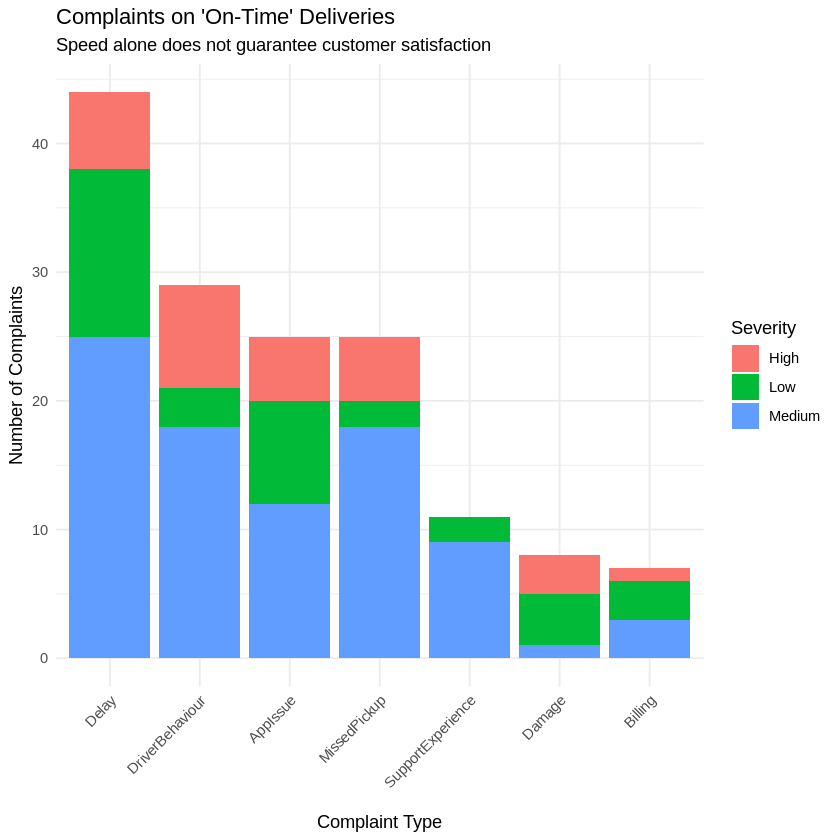

In [4]:
# ============================================================
# QUERY 1: On-Time deliveries with customer complaints
# Tests whether delivery speed masks service quality issues
# ============================================================

q1_on_time_complaints <- sqldf("
  SELECT
    d.delivery_status,
    c.complaint_type,
    c.severity,
    COUNT(*) AS complaint_count
  FROM deliveries d
  INNER JOIN orders o ON d.order_id = o.order_id
  INNER JOIN complaints c ON o.order_id = c.order_id
  WHERE d.delivery_status = 'OnTime'
  GROUP BY d.delivery_status, c.complaint_type, c.severity
  ORDER BY complaint_count DESC
")

print(q1_on_time_complaints)

# Visualise
ggplot(q1_on_time_complaints,
       aes(x = reorder(complaint_type, -complaint_count),
           y = complaint_count,
           fill = severity)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    title = "Complaints on 'On-Time' Deliveries",
    subtitle = "Speed alone does not guarantee customer satisfaction",
    x = "Complaint Type",
    y = "Number of Complaints",
    fill = "Severity"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

  zone_standardised total_orders total_complaints complaint_rate_pct
1             NORTH          174               53               30.5
2         RIVERSIDE          151               45               29.8
3           CENTRAL          158               42               26.6
4             SOUTH          181               46               25.4
5              EAST          207               50               24.2
6               CTR           80               18               22.5
7           AIRPORT          144               32               22.2
8              WEST          155               34               21.9
  avg_compensation high_severity_count
1            21.59                  18
2            20.12                   9
3            24.14                  14
4            17.45                   6
5            22.01                  12
6            16.11                   5
7            14.35                   3
8            22.81                  10


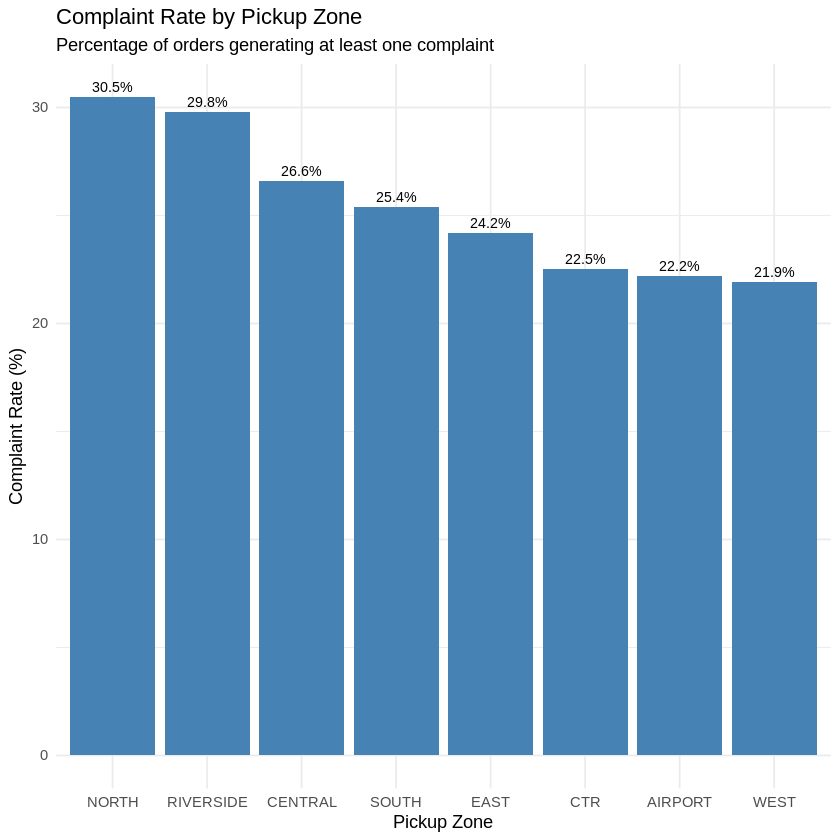

In [5]:
# ============================================================
# QUERY 2: Complaint rate by pickup zone
# Identifies which zones consistently underperform
# ============================================================

q2_zone_complaints <- sqldf("
  SELECT
    UPPER(TRIM(o.pickup_zone)) AS zone_standardised,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT c.complaint_id) AS total_complaints,
    ROUND(COUNT(DISTINCT c.complaint_id) * 100.0 / COUNT(DISTINCT o.order_id), 1) AS complaint_rate_pct,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation,
    COUNT(CASE WHEN c.severity = 'High' THEN 1 END) AS high_severity_count
  FROM orders o
  LEFT JOIN complaints c ON o.order_id = c.order_id
  WHERE o.pickup_zone IS NOT NULL AND o.pickup_zone != ''
  GROUP BY UPPER(TRIM(o.pickup_zone))
  HAVING total_orders >= 20
  ORDER BY complaint_rate_pct DESC
")

print(q2_zone_complaints)

# Visualise
ggplot(q2_zone_complaints,
       aes(x = reorder(zone_standardised, -complaint_rate_pct),
           y = complaint_rate_pct)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = paste0(complaint_rate_pct, "%")),
            vjust = -0.5, size = 3) +
  labs(
    title = "Complaint Rate by Pickup Zone",
    subtitle = "Percentage of orders generating at least one complaint",
    x = "Pickup Zone",
    y = "Complaint Rate (%)"
  ) +
  theme_minimal()

   override_category delivery_status delivery_count avg_distance_km avg_rating
1       No Overrides         Delayed             77            12.7       2.97
2       No Overrides          Failed             46            13.2       3.13
3       No Overrides          OnTime            269            12.6       4.30
4         1 Override         Delayed             65            13.9       3.25
5         1 Override          Failed             51            12.9       3.19
6         1 Override          OnTime            191            13.9       4.29
7      2-3 Overrides         Delayed             46            17.5       3.21
8      2-3 Overrides          Failed             31            13.9       2.70
9      2-3 Overrides          OnTime            129            15.5       4.25
10      4+ Overrides         Delayed              9            18.1       2.96
11      4+ Overrides          Failed              3            17.5       2.98
12      4+ Overrides          OnTime             19 

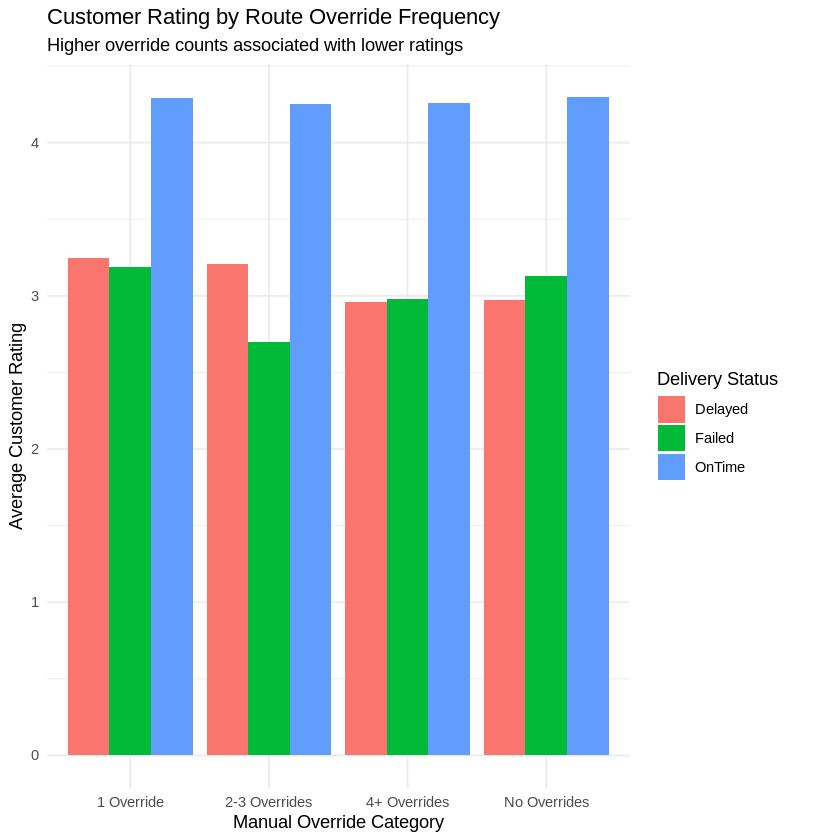

In [6]:
# ============================================================
# QUERY 3: Route overrides and delivery outcomes
# The case study flags unusually high manual overrides
# ============================================================

q3_overrides <- sqldf("
  SELECT
    CASE
      WHEN d.manual_route_override_count = 0 THEN 'No Overrides'
      WHEN d.manual_route_override_count = 1 THEN '1 Override'
      WHEN d.manual_route_override_count BETWEEN 2 AND 3 THEN '2-3 Overrides'
      ELSE '4+ Overrides'
    END AS override_category,
    d.delivery_status,
    COUNT(*) AS delivery_count,
    ROUND(AVG(d.route_distance_km), 1) AS avg_distance_km,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  WHERE d.customer_rating_post_delivery IS NOT NULL
  GROUP BY override_category, d.delivery_status
  ORDER BY
    CASE override_category
      WHEN 'No Overrides' THEN 1
      WHEN '1 Override' THEN 2
      WHEN '2-3 Overrides' THEN 3
      ELSE 4
    END,
    d.delivery_status
")

print(q3_overrides)

# Visualise
ggplot(q3_overrides,
       aes(x = override_category, y = avg_rating, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Customer Rating by Route Override Frequency",
    subtitle = "Higher override counts associated with lower ratings",
    x = "Manual Override Category",
    y = "Average Customer Rating",
    fill = "Delivery Status"
  ) +
  theme_minimal()

   battery_health_category vehicle_type total_deliveries failed_deliveries
1            Fair (60-79%)       Diesel               76                14
2            Fair (60-79%)       Hybrid               70                11
3            Fair (60-79%)     CargoVan              144                21
4            Fair (60-79%)           EV              153                15
5              Good (80%+)       Diesel               42                 9
6              Good (80%+)       Hybrid              120                22
7              Good (80%+)     CargoVan               45                 7
8              Good (80%+)           EV              180                15
9            Poor (40-59%)     CargoVan               34                10
10           Poor (40-59%)       Diesel               26                 3
11           Poor (40-59%)       Hybrid               35                 3
   failure_rate_pct avg_cost
1              18.4    12.97
2              15.7    12.14
3            

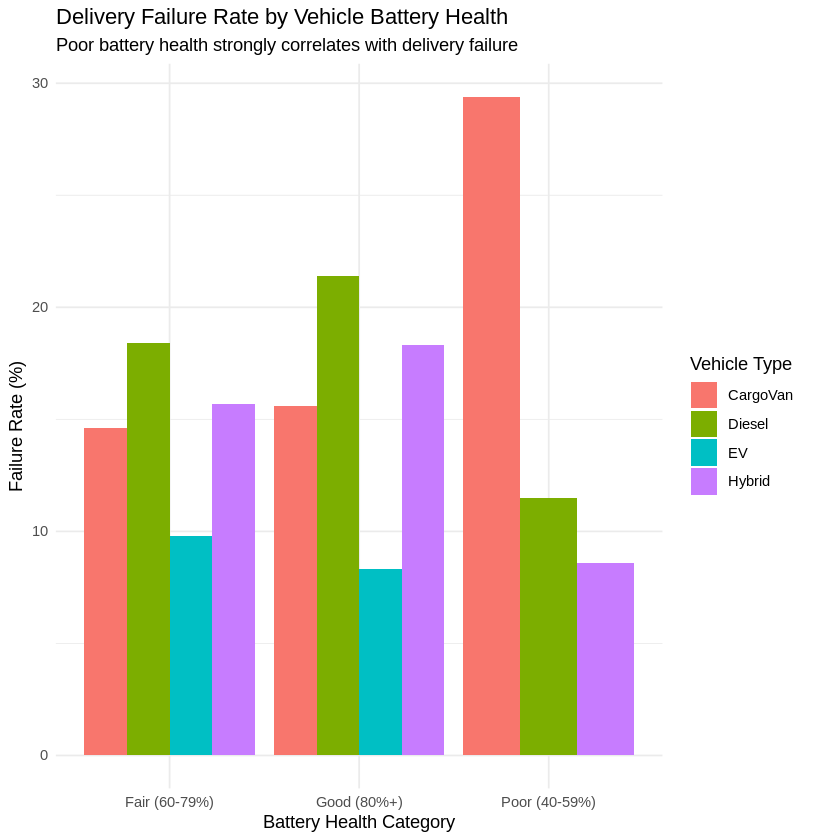

In [7]:
# ============================================================
# QUERY 4: Vehicle battery health vs delivery failure rate
# The case study notes vehicle downtime is rising
# ============================================================

q4_vehicle_health <- sqldf("
  SELECT
    CASE
      WHEN v.battery_health_pct >= 80 THEN 'Good (80%+)'
      WHEN v.battery_health_pct >= 60 THEN 'Fair (60-79%)'
      WHEN v.battery_health_pct >= 40 THEN 'Poor (40-59%)'
      ELSE 'Critical (<40%)'
    END AS battery_health_category,
    v.vehicle_type,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  INNER JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  WHERE v.battery_health_pct IS NOT NULL
  GROUP BY battery_health_category, v.vehicle_type
  ORDER BY battery_health_category, failure_rate_pct DESC
")

print(q4_vehicle_health)

# Visualise
ggplot(q4_vehicle_health,
       aes(x = battery_health_category, y = failure_rate_pct, fill = vehicle_type)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Delivery Failure Rate by Vehicle Battery Health",
    subtitle = "Poor battery health strongly correlates with delivery failure",
    x = "Battery Health Category",
    y = "Failure Rate (%)",
    fill = "Vehicle Type"
  ) +
  theme_minimal()

      training_category employment_type delivery_count avg_rating avg_distance
1    Proficient (70-84)        Contract             56       3.86         12.3
2    Proficient (70-84)        FullTime            280       3.89         14.1
3    Proficient (70-84)        PartTime            124       3.83         14.2
4  Needs Training (<55)        Contract             16       3.96         13.4
5  Needs Training (<55)        FullTime              7       3.21         10.4
6  Needs Training (<55)        PartTime              6       3.63         20.1
7          Expert (85+)        Contract             25       3.92         10.6
8          Expert (85+)        FullTime            114       3.85         13.7
9          Expert (85+)        PartTime             28       3.77         10.7
10   Developing (55-69)        Contract             12       3.33         13.1
11   Developing (55-69)        FullTime            160       3.86         14.4
12   Developing (55-69)        PartTime             

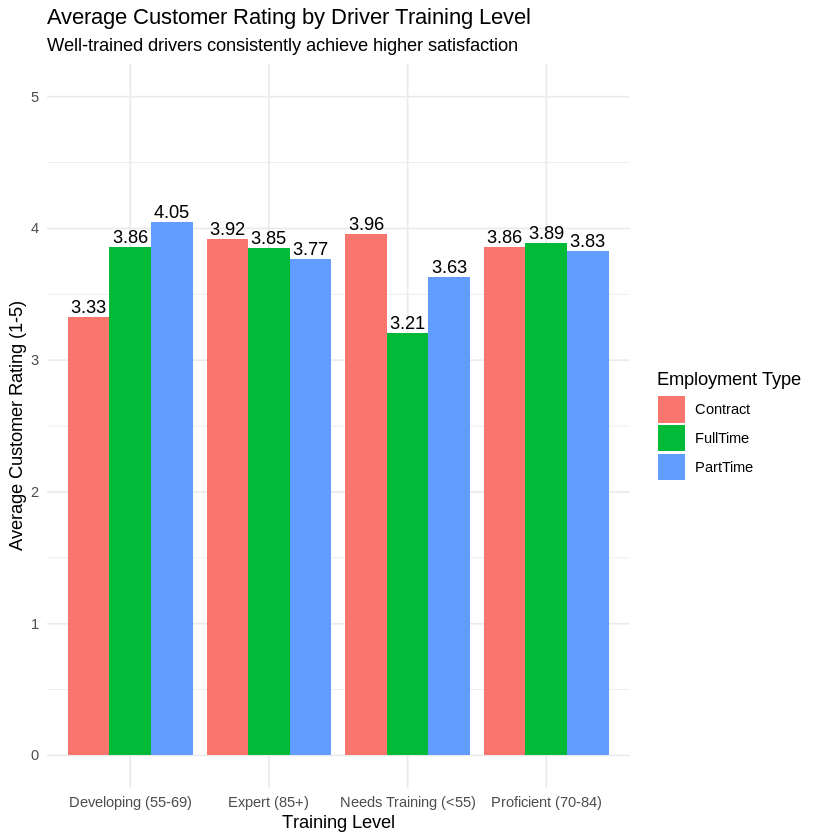

In [8]:
# ============================================================
# QUERY 5: Driver training score vs customer ratings
# ============================================================

q5_driver_training <- sqldf("
  SELECT
    CASE
      WHEN d.training_score >= 85 THEN 'Expert (85+)'
      WHEN d.training_score >= 70 THEN 'Proficient (70-84)'
      WHEN d.training_score >= 55 THEN 'Developing (55-69)'
      ELSE 'Needs Training (<55)'
    END AS training_category,
    d.employment_type,
    COUNT(dl.delivery_id) AS delivery_count,
    ROUND(AVG(dl.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(dl.route_distance_km), 1) AS avg_distance,
    SUM(CASE WHEN dl.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count
  FROM drivers d
  INNER JOIN deliveries dl ON d.driver_id = dl.driver_id
  WHERE d.training_score IS NOT NULL
    AND dl.customer_rating_post_delivery IS NOT NULL
  GROUP BY training_category, d.employment_type
  ORDER BY training_category DESC
")

print(q5_driver_training)

# Visualise
ggplot(q5_driver_training,
       aes(x = training_category, y = avg_rating, fill = employment_type)) +
  geom_bar(stat = "identity", position = "dodge") +
  geom_text(aes(label = avg_rating), position = position_dodge(0.9), vjust = -0.3) +
  labs(
    title = "Average Customer Rating by Driver Training Level",
    subtitle = "Well-trained drivers consistently achieve higher satisfaction",
    x = "Training Level",
    y = "Average Customer Rating (1-5)",
    fill = "Employment Type"
  ) +
  ylim(0, 5) +
  theme_minimal()

        hub_name      zone  hub_type capacity_score total_deliveries
1   Central Core   Central   Control             88              115
2 North Exchange     North  Dispatch             82              136
3    Airport Hub   Airport  Dispatch             71              104
4  Riverside Hub Riverside Warehouse             66              115
5  Midtown Relay   Central  Charging             63              128
6      East Dock      East Warehouse             74              119
7      West Gate      West  Dispatch             69              127
8     South Link     South  Dispatch             78              106
  on_time_count failed_count on_time_rate avg_rating avg_overrides
1            67           23         58.3       3.67           0.9
2            93           17         68.4       3.84           1.0
3            62           15         59.6       3.88           0.9
4            76           14         66.1       3.88           1.1
5            80           26         62.5   

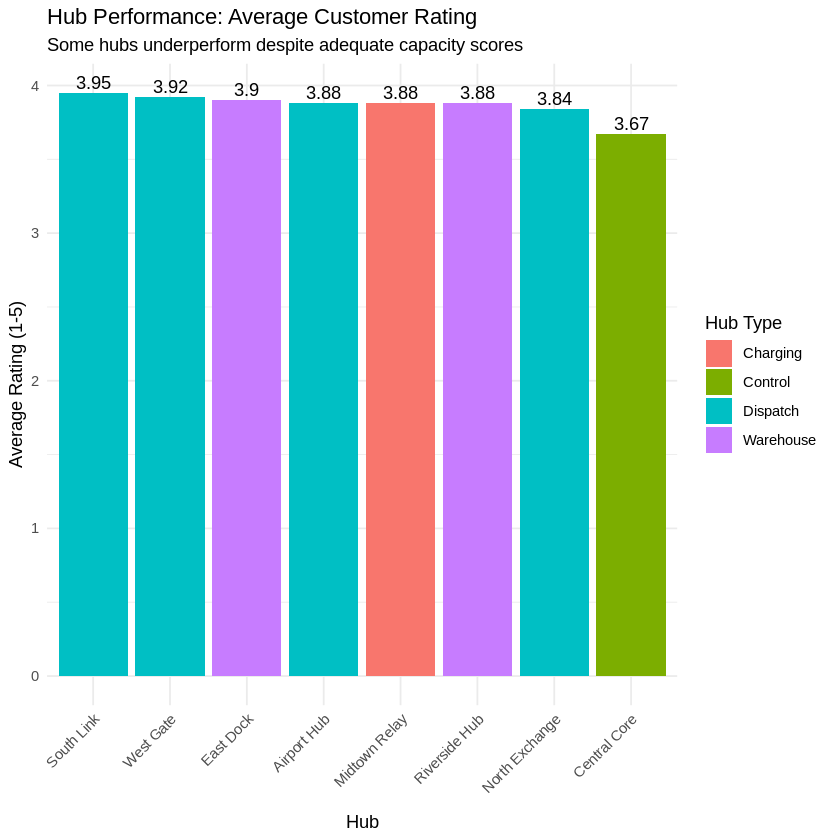

In [9]:
# ============================================================
# QUERY 6: Hub performance beyond simple volume metrics
# ============================================================

q6_hub_performance <- sqldf("
  SELECT
    h.hub_name,
    h.zone,
    h.hub_type,
    h.capacity_score,
    COUNT(dl.delivery_id) AS total_deliveries,
    SUM(CASE WHEN dl.delivery_status = 'OnTime' THEN 1 ELSE 0 END) AS on_time_count,
    SUM(CASE WHEN dl.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count,
    ROUND(SUM(CASE WHEN dl.delivery_status = 'OnTime' THEN 1 ELSE 0 END) * 100.0 / COUNT(dl.delivery_id), 1) AS on_time_rate,
    ROUND(AVG(dl.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(dl.manual_route_override_count), 1) AS avg_overrides,
    ROUND(AVG(dl.fuel_or_charge_cost), 2) AS avg_cost_per_delivery
  FROM hubs h
  INNER JOIN deliveries dl ON h.hub_id = dl.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type, h.capacity_score
  ORDER BY avg_rating ASC
")

print(q6_hub_performance)

# Visualise
ggplot(q6_hub_performance,
       aes(x = reorder(hub_name, -avg_rating), y = avg_rating, fill = hub_type)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = avg_rating), vjust = -0.3) +
  labs(
    title = "Hub Performance: Average Customer Rating",
    subtitle = "Some hubs underperform despite adequate capacity scores",
    x = "Hub",
    y = "Average Rating (1-5)",
    fill = "Hub Type"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

      incident_type severity incident_count avg_resolution_hours still_open
1    RouteDeviation      Low             17                 16.0          4
2      BatteryAlert   Medium             16                 11.1          6
3      VehicleFault   Medium             16                  5.8          6
4    CustomerNoShow      Low             15                 14.1          6
5      AppSyncError   Medium             13                 11.9          2
6    CustomerNoShow   Medium             13                 14.1          2
7  TemperatureIssue   Medium             13                 16.3          3
8      ProofMissing      Low             12                 14.9          1
9      ProofMissing   Medium             12                 11.0          3
10   RouteDeviation     High             12                 13.1          6
11     ProofMissing     High             10                  4.7          3
12     AppSyncError      Low              9                 15.3          4
13   Custome

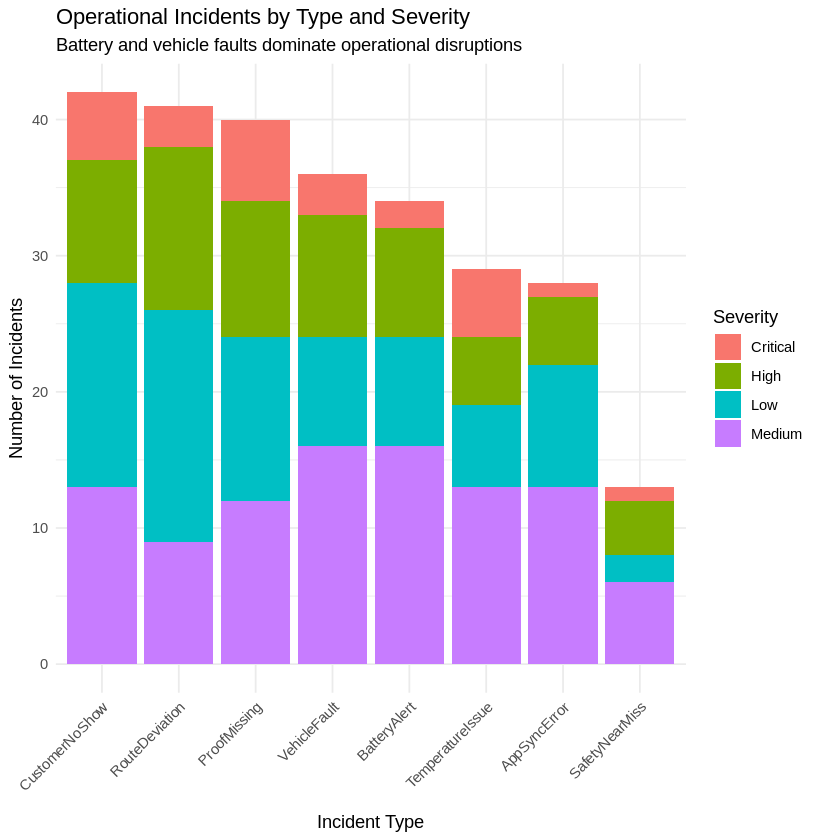

In [10]:
# ============================================================
# QUERY 7: Incident analysis - types, frequency, resolution time
# ============================================================

q7_incidents <- sqldf("
  SELECT
    i.incident_type,
    i.severity,
    COUNT(*) AS incident_count,
    ROUND(AVG(i.resolved_hours), 1) AS avg_resolution_hours,
    SUM(CASE WHEN i.resolution_status = 'Open' THEN 1 ELSE 0 END) AS still_open,
    SUM(CASE WHEN i.resolution_status = 'Escalated' THEN 1 ELSE 0 END) AS escalated
  FROM incidents i
  WHERE i.resolved_hours IS NOT NULL
  GROUP BY i.incident_type, i.severity
  ORDER BY incident_count DESC
")

print(q7_incidents)

# Visualise
ggplot(q7_incidents,
       aes(x = reorder(incident_type, -incident_count),
           y = incident_count,
           fill = severity)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Operational Incidents by Type and Severity",
    subtitle = "Battery and vehicle faults dominate operational disruptions",
    x = "Incident Type",
    y = "Number of Incidents",
    fill = "Severity"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

   customer_id customer_type home_zone loyalty_score total_orders total_spend
1        C0545      Consumer     SOUTH          66.9            6     1433.51
2        C0622      Consumer RiverSide          54.2            6      732.93
3        C0157      Consumer   CENTRAL          67.9            4      720.04
4        C0372      Consumer      West          26.2            6      669.11
5        C0172      Consumer     north          75.4            4      625.45
6        C0476      Consumer     NORTH          66.0            5      587.86
7        C0023      Consumer     South          73.1            6      582.99
8        C0335           SME     NORTH          45.3            6      522.80
9        C0012      Consumer   Airport          46.3            3      494.36
10       C0028      Consumer       Ctr          78.5            3      481.47
11       C0529           SME Riverside          43.2            5      473.10
12       C0599      Consumer     North          81.4            

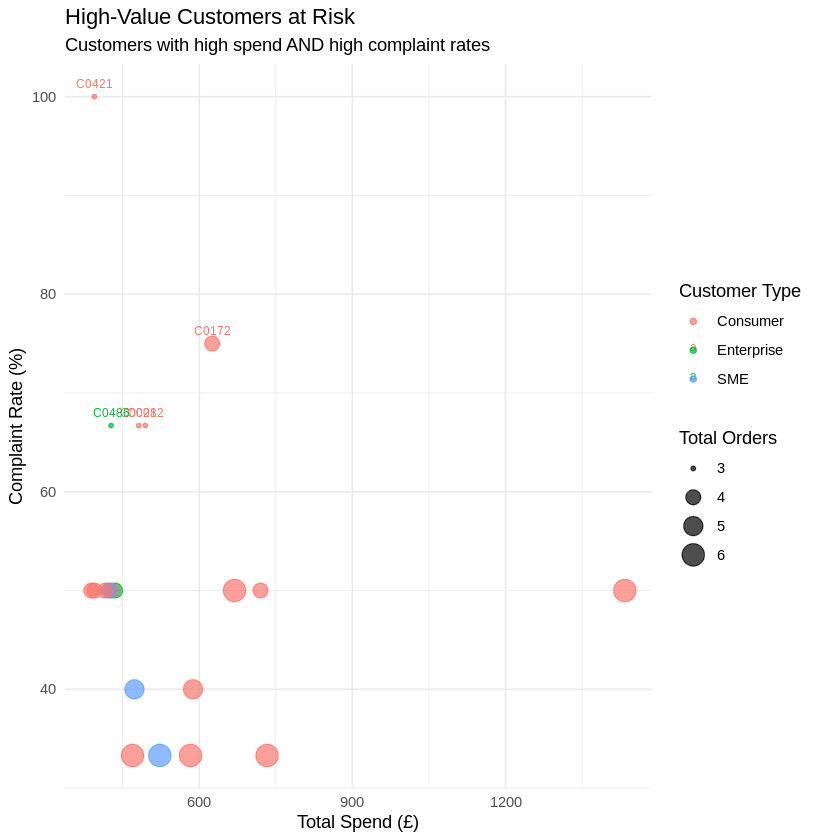

In [11]:
# ============================================================
# QUERY 8: Repeat complainers among high-value customers
# ============================================================

q8_customer_risk <- sqldf("
  SELECT
    c.customer_id,
    c.customer_type,
    c.home_zone,
    c.loyalty_score,
    COUNT(DISTINCT o.order_id) AS total_orders,
    SUM(o.order_value) AS total_spend,
    COUNT(DISTINCT comp.complaint_id) AS complaint_count,
    ROUND(SUM(o.order_value) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value,
    ROUND(COUNT(DISTINCT comp.complaint_id) * 100.0 / COUNT(DISTINCT o.order_id), 1) AS complaint_rate
  FROM customers c
  INNER JOIN orders o ON c.customer_id = o.customer_id
  LEFT JOIN complaints comp ON o.order_id = comp.order_id
  WHERE c.loyalty_score IS NOT NULL
  GROUP BY c.customer_id, c.customer_type, c.home_zone, c.loyalty_score
  HAVING COUNT(DISTINCT o.order_id) >= 3
     AND COUNT(DISTINCT comp.complaint_id) >= 2
  ORDER BY total_spend DESC
  LIMIT 20
")

print(q8_customer_risk)

# Visualise
ggplot(q8_customer_risk,
       aes(x = total_spend, y = complaint_rate, size = total_orders, color = customer_type)) +
  geom_point(alpha = 0.7) +
  geom_text(aes(label = customer_id), vjust = -1, size = 2.5,
            data = subset(q8_customer_risk, complaint_rate > 50)) +
  labs(
    title = "High-Value Customers at Risk",
    subtitle = "Customers with high spend AND high complaint rates",
    x = "Total Spend (£)",
    y = "Complaint Rate (%)",
    size = "Total Orders",
    color = "Customer Type"
  ) +
  theme_minimal()